# Automotive Part Image-Text Matching — Dataset V2

## Final Deep Learning Exam Project

**Research question:** Can a neural model that combines an automotive-part image and a short text description classify their relationship better than image-only, text-only, and non-neural baselines?

The relation labels are:

- **MATCH** — image and text refer to the same part category;
- **PARTIAL_MATCH** — the categories differ but belong to the same automotive system;
- **MISMATCH** — the categories belong to different systems.

This notebook is the executed research report. All numerical conclusions below are loaded from saved artifacts generated by the project pipeline; the locked test CSV is never read here.

## 1. Problem statement and practical motivation

Automotive warehouses, online catalogues, and service operations frequently need to check whether a product photograph agrees with a textual listing. A wrong association can cause incorrect picking, poor search results, or a misleading catalogue entry. The task is genuinely multimodal: the relation cannot be determined reliably from the image or the text alone because each image is intentionally paired with descriptions from all three relation classes.

The project is a controlled course experiment rather than a production deployment. Its purpose is to compare transparent baselines with compact PyTorch neural models under a leakage-aware experimental design.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

ROOT = Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"

manifest = pd.read_csv(DATA / "image_manifest.csv")
provenance = pd.read_csv(DATA / "dataset_v2_manifest.csv")
train = pd.read_csv(DATA / "train.csv")
validation = pd.read_csv(DATA / "validation.csv")
model_comparison = pd.read_csv(RESULTS / "model_comparison.csv")
predictions = pd.read_csv(RESULTS / "validation_predictions.csv")
main_predictions = pd.read_csv(RESULTS / "multimodal_validation_predictions.csv")
paired = pd.read_csv(RESULTS / "paired_comparisons.csv")
audit = json.loads((RESULTS / "data_audit.json").read_text(encoding="utf-8"))
run_info = json.loads((RESULTS / "run_info.json").read_text(encoding="utf-8"))
verification = json.loads((RESULTS / "verification_summary.json").read_text(encoding="utf-8"))

print(f"Dataset version: {run_info['dataset_version']}")
print(f"Python: {run_info['python_version']} | PyTorch: {run_info['torch_version']}")
print(f"Verification status before this execution: {verification.get('status')}")

Dataset version: 2.0
Python: 3.13.13 | PyTorch: 2.13.0+cpu
Verification status before this execution: PENDING_NOTEBOOK_REEXECUTION


## 2. Data acquisition, licensing, and Dataset V2

Dataset V2 combines three source groups:

1. the original manually attributed Wikimedia Commons photographs;
2. a hybrid imported real-image subset: eight overlapping categories from the Apache-2.0 **50 Types of Car Parts** Kaggle dataset and two missing categories from open-license Wikimedia Commons files;
3. simple synthetic drawings retained only for a training ablation.

The importer validates files, applies EXIF orientation, converts to RGB, standardizes selected images to 224×224 pixels, computes SHA-256 and perceptual hashes, and rejects near duplicates before assigning images to training or validation. Each imported image records its provider, source page, attribution, license, hashes, and transformation. The original Wikimedia test images remain sealed.

The number of paired rows is larger than the number of independent images. Every image contributes six rows — two per relation label — so all uncertainty calculations and paired model tests treat the **image** as the independent unit.

In [2]:
image_summary = (
    manifest.groupby(["split", "source"])
    .size()
    .rename("independent_images")
    .reset_index()
)
row_summary = pd.DataFrame({
    "split": ["train", "validation"],
    "paired_rows": [len(train), len(validation)],
    "independent_images": [train.image_id.nunique(), validation.image_id.nunique()],
    "unique_descriptions": [train.description.nunique(), validation.description.nunique()],
})

display(image_summary)
display(row_summary)

provider_summary = provenance.groupby(["provider", "assigned_split"]).size().rename("images").reset_index()
display(provider_summary)

,split,source,independent_images
0,test,wikimedia,10
1,train,dataset_v2,50
2,train,generated,50
3,train,wikimedia,50
4,validation,dataset_v2,10
5,validation,wikimedia,10


,split,paired_rows,independent_images,unique_descriptions
0,train,900,150,40
1,validation,120,20,20


,provider,assigned_split,images
0,Kaggle,train,40
1,Kaggle,validation,8
2,Wikimedia Commons,train,10
3,Wikimedia Commons,validation,2


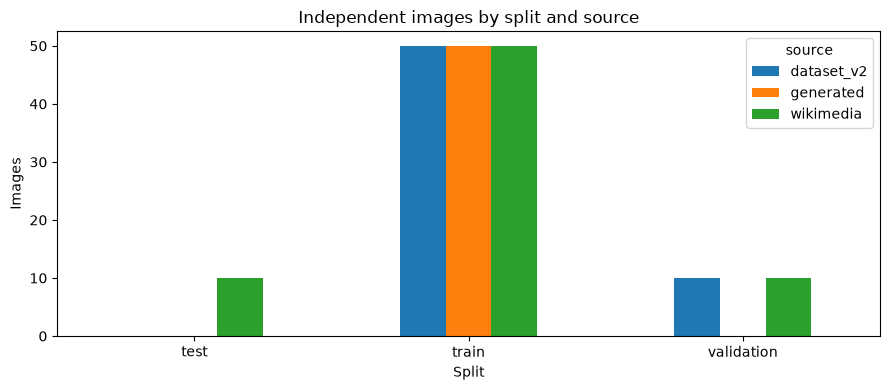

In [3]:
source_plot = image_summary.pivot(index="split", columns="source", values="independent_images").fillna(0)
ax = source_plot.plot(kind="bar", figsize=(9, 4))
ax.set_title("Independent images by split and source")
ax.set_xlabel("Split")
ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 3. Leakage controls and statistical validity

The pipeline checks identity, path, object-group, exact-image-hash, exact-caption, and near-image overlap. Alternate Wikimedia views known to depict the same object are grouped. The Dataset V2 importer rejects candidate photographs that are too similar to already accepted images according to both difference hash and normalized grayscale cosine similarity.

Because multiple rows share one image, resampling individual rows would exaggerate the effective sample size. Confidence intervals therefore bootstrap complete image groups. Paired comparisons use an image-group sign-flip randomization test: exact enumeration for small samples and a deterministic Monte Carlo approximation for the larger Dataset V2 validation set.

In [4]:
leakage_checks = pd.Series({
    "part_group_overlap": audit["overlap"]["part_group_overlap"],
    "object_group_overlap": audit["overlap"]["object_group_overlap"],
    "image_id_overlap": audit["overlap"]["image_id_overlap"],
    "image_path_overlap": audit["overlap"]["image_path_overlap"],
    "exact_image_hash_overlap": audit["exact_cross_split_image_hash_overlap"],
    "exact_description_overlap": audit["exact_description_overlap"],
    "suspicious_near_image_pairs": audit["suspicious_real_image_pairs"],
})
display(leakage_checks.to_frame("count"))

assert (leakage_checks == 0).all()
assert audit["test_split_used"] is False
assert audit["test_lock"]["sha256_matches"] is True

,count
part_group_overlap,0
object_group_overlap,0
image_id_overlap,0
image_path_overlap,0
exact_image_hash_overlap,0
exact_description_overlap,0
suspicious_near_image_pairs,0


## 4. Experimental models

The comparison contains four non-neural baselines and four PyTorch models:

- majority baseline;
- TF-IDF plus Logistic Regression;
- low-resolution image pixels plus Logistic Regression;
- concatenated image and text features plus Logistic Regression;
- neural text MLP;
- image-only CNN;
- multimodal CNN plus text MLP trained on real images only;
- the same multimodal network trained on real and synthetic images.

The multimodal model has auxiliary image-category and text-category heads during training. Only the three-class relation head is used for the final score. The image-only model is intentionally expected to remain near the theoretical one-third ceiling because each image appears equally often with every relation label.

In [5]:
comparison_view = model_comparison[[
    "model", "modality", "training_data", "validation_accuracy", "validation_macro_f1",
    "accuracy_ci_low", "accuracy_ci_high", "correct_predictions", "total_predictions"
]].copy()
display(comparison_view)

,model,modality,training_data,validation_accuracy,validation_macro_f1,accuracy_ci_low,accuracy_ci_high,correct_predictions,total_predictions
0,PyTorch multimodal CNN (real-only training),image + text,100 real train images,0.458333,0.441385,0.300000,0.616667,55,120
1,PyTorch multimodal CNN (real + synthetic train...,image + text,100 real + 50 synthetic train images,0.416667,0.412096,0.274792,0.566667,50,120
2,PyTorch neural text model,text,all train rows,0.333333,0.213444,0.291667,0.375000,40,120
3,Image + text Logistic Regression,image + text,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
4,Image pixels + Logistic Regression,image,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
5,Majority baseline,none,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
6,PyTorch CNN image model,image,all train rows,0.333333,0.166667,0.333333,0.333333,40,120
7,TF-IDF + Logistic Regression,text,all train rows,0.333333,0.166667,0.333333,0.333333,40,120


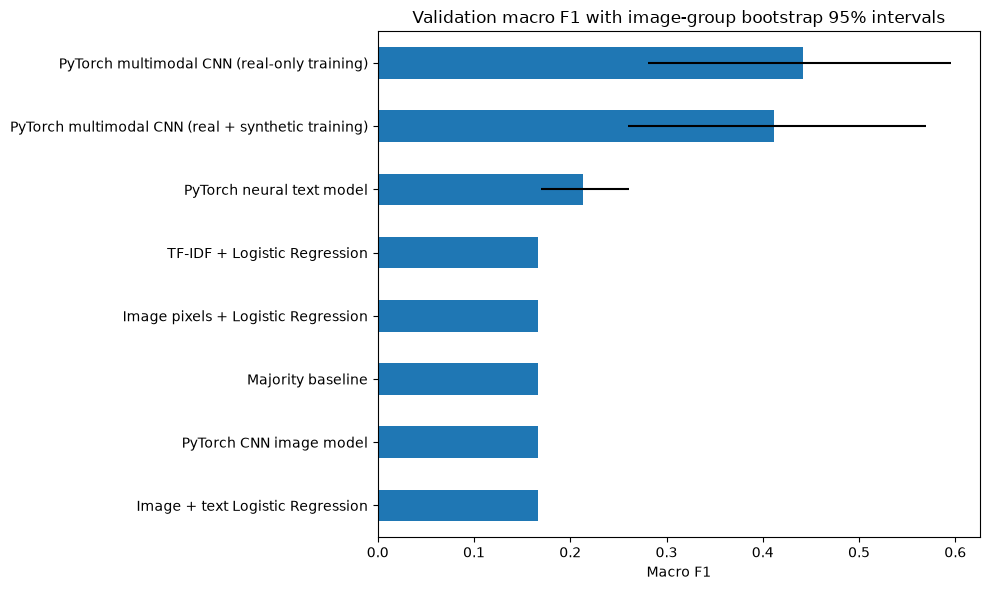

In [6]:
plot_table = model_comparison.sort_values("validation_macro_f1")
errors = np.vstack([
    plot_table["validation_macro_f1"] - plot_table["macro_f1_ci_low"],
    plot_table["macro_f1_ci_high"] - plot_table["validation_macro_f1"],
])
ax = plot_table.plot(
    x="model",
    y="validation_macro_f1",
    kind="barh",
    xerr=errors,
    legend=False,
    figsize=(10, 6),
)
ax.set_title("Validation macro F1 with image-group bootstrap 95% intervals")
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Main-model error analysis

The confusion matrix and class report are derived from the real-only multimodal CNN predictions. The evaluation contains balanced relation labels, but the rows are not independent; the image count reported earlier is the correct experimental sample size.

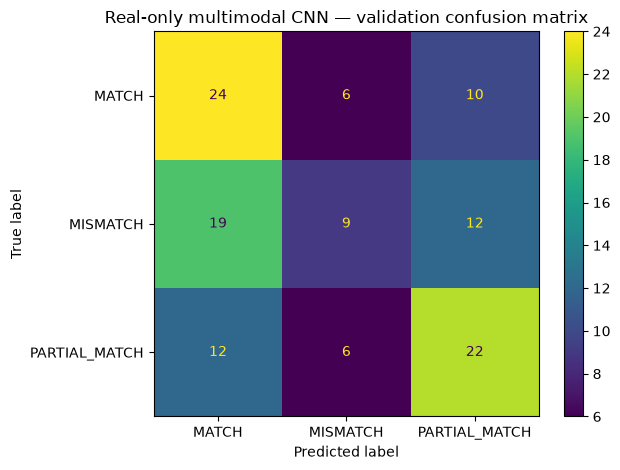

,precision,recall,f1-score,support
MATCH,0.436364,0.600000,0.505263,40.000000
MISMATCH,0.428571,0.225000,0.295082,40.000000
PARTIAL_MATCH,0.500000,0.550000,0.523810,40.000000
accuracy,0.458333,0.458333,0.458333,0.458333
macro avg,0.454978,0.458333,0.441385,120.000000
weighted avg,0.454978,0.458333,0.441385,120.000000


In [7]:
labels = ["MATCH", "MISMATCH", "PARTIAL_MATCH"]
cm = confusion_matrix(
    main_predictions["true_label"],
    main_predictions["predicted_label"],
    labels=labels,
)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(values_format="d")
plt.title("Real-only multimodal CNN — validation confusion matrix")
plt.tight_layout()
plt.show()

report = pd.DataFrame(
    classification_report(
        main_predictions["true_label"],
        main_predictions["predicted_label"],
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
).T
display(report)

,part_category,samples,correct,accuracy,macro_f1
0,air_filter,12,9,0.750000,0.696296
1,alternator,12,4,0.333333,0.269360
2,brake_disc,12,5,0.416667,0.410053
3,brake_pad,12,5,0.416667,0.419048
4,coil_spring,12,1,0.083333,0.074074
5,headlight,12,5,0.416667,0.414815
6,oil_filter,12,2,0.166667,0.133333
7,shock_absorber,12,4,0.333333,0.333333
8,starter,12,10,0.833333,0.814815
9,taillight,12,10,0.833333,0.822222


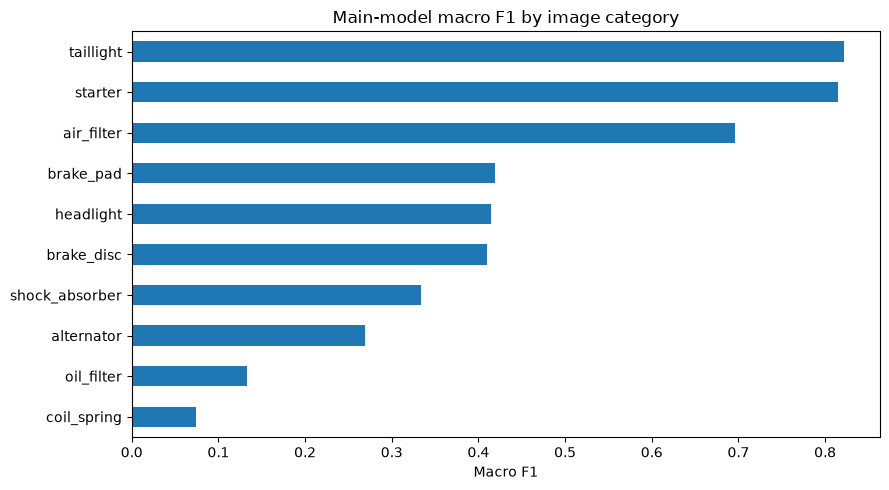

In [8]:
per_category = pd.read_csv(RESULTS / "multimodal_per_category.csv")
display(per_category)

ax = per_category.sort_values("macro_f1").plot(
    x="part_category", y="macro_f1", kind="barh", legend=False, figsize=(9, 5)
)
ax.set_title("Main-model macro F1 by image category")
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [9]:
errors = main_predictions.loc[
    ~main_predictions["is_correct"],
    ["part_category", "text_category", "description", "true_label", "predicted_label", "image_path"],
]
display(errors.head(15))
print(f"Errors: {len(errors)} of {len(main_predictions)} paired rows")

,part_category,text_category,description,true_label,predicted_label,image_path
2,air_filter,alternator,The pictured part is a automotive alternator; ...,MISMATCH,MATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
5,air_filter,brake_pad,A automotive brake pad associated with the dis...,MISMATCH,MATCH,data/images/dataset_v2/air_filter/dataset_v2_a...
8,air_filter,brake_disc,A brake disc or rotor associated with the disc...,MISMATCH,PARTIAL_MATCH,data/images/wikimedia/air_filter/commons_air_f...
12,alternator,alternator,The pictured part is a automotive alternator; ...,MATCH,PARTIAL_MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
13,alternator,starter,The pictured part is a automotive starter moto...,PARTIAL_MATCH,MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
14,alternator,brake_disc,The pictured part is a brake disc or rotor; it...,MISMATCH,MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
15,alternator,alternator,A automotive alternator associated with the ve...,MATCH,PARTIAL_MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
16,alternator,starter,A automotive starter motor associated with the...,PARTIAL_MATCH,MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
17,alternator,shock_absorber,A suspension shock absorber associated with th...,MISMATCH,MATCH,data/images/dataset_v2/alternator/dataset_v2_a...
20,alternator,coil_spring,A suspension coil spring associated with the v...,MISMATCH,MATCH,data/images/wikimedia/alternator/commons_alter...


Errors: 65 of 120 paired rows


## 6. Paired comparisons and synthetic-data ablation

A model can appear better by chance, particularly when the effective sample is modest. The table below compares correctness on the same image groups. The p-value is not interpreted as a binary pass/fail label; it is one part of the evidence together with effect size, confidence intervals, class behaviour, and known limitations.

In [10]:
display(paired)

display(model_comparison.loc[
    model_comparison["model_slug"].isin([
        "torch_multimodal_real_only",
        "torch_multimodal_real_plus_synthetic",
    ]),
    ["model", "validation_accuracy", "validation_macro_f1", "accuracy_ci_low", "accuracy_ci_high"],
])

,left_model_slug,right_model_slug,method,group_column,independent_groups,paired_rows,left_correct_total,right_correct_total,observed_correct_difference,observed_accuracy_difference,left_better_groups,right_better_groups,tied_groups,left_correct_right_wrong_rows,left_wrong_right_correct_rows,row_discordant_predictions,randomization_assignments,randomization_seed,grouped_two_sided_p_value
0,torch_multimodal_real_only,image_text_logistic_regression,exact_image_group_sign_flip,image_id,20,120,55,40,15,0.125000,11,8,1,31,16,47,1048576,NaN,0.178581
1,torch_multimodal_real_only,torch_multimodal_real_plus_synthetic,exact_image_group_sign_flip,image_id,20,120,55,50,5,0.041667,7,9,4,22,17,39,1048576,NaN,0.718536


,model,validation_accuracy,validation_macro_f1,accuracy_ci_low,accuracy_ci_high
0,PyTorch multimodal CNN (real-only training),0.458333,0.441385,0.300000,0.616667
1,PyTorch multimodal CNN (real + synthetic train...,0.416667,0.412096,0.274792,0.566667


## 7. Previous research

The project is intentionally smaller than established image-text benchmarks, but its design is informed by earlier work:

1. Faghri et al., **VSE++: Improving Visual-Semantic Embeddings with Hard Negatives**, BMVC 2018 — hard-negative learning for image-text retrieval.
2. Li et al., **VisualBERT: A Simple and Performant Baseline for Vision and Language**, 2019 — joint visual-language representations.
3. Radford et al., **Learning Transferable Visual Models From Natural Language Supervision (CLIP)**, ICML 2021 — large-scale contrastive image-text pretraining.
4. He et al., **Deep Residual Learning for Image Recognition**, CVPR 2016 — residual vision architectures and transfer-learning context.
5. Gpiosenka, **50 Types of Car Parts — Image Classification**, Kaggle, Apache-2.0 — source for eight overlapping automotive-part categories.
6. **Wikimedia Commons** — open-license source for the additional air-filter and shock-absorber photographs, with per-file attribution preserved in the Dataset V2 manifest.

The current project does not claim benchmark comparability with those works. It uses a compact supervised relation classifier to test the course-level research question under limited computational and data resources.

## 8. Limitations and threats to validity

- Validation is used for model selection, so it is development evidence rather than a final unbiased estimate.
- The final Wikimedia test set remains locked and must be evaluated only once after every modelling decision is frozen.
- Multiple text pairs share each image; image-group methods are therefore mandatory.
- Part names remain visible in the descriptions. The task studies cross-modal relation classification, not open-vocabulary language understanding.
- The hybrid imported subset is larger and more diverse than the original data, but public sources may still contain source-specific visual conventions, label noise, or imperfect metadata.
- The synthetic drawings are simple templates and are not treated as independent real-world evidence.

In [11]:
main = model_comparison.set_index("model_slug").loc["torch_multimodal_real_only"]
baseline = model_comparison.set_index("model_slug").loc["image_text_logistic_regression"]
pair = paired.loc[paired["right_model_slug"].eq("image_text_logistic_regression")].iloc[0]

summary = f'''
## 9. Conclusion

On the Dataset V2 real-image validation set, the selected multimodal CNN achieved **{main.validation_accuracy:.4f} accuracy** and **{main.validation_macro_f1:.4f} macro F1** ({int(main.correct_predictions)}/{int(main.total_predictions)} correct paired rows). The non-neural image-plus-text baseline achieved **{baseline.validation_accuracy:.4f} accuracy** and **{baseline.validation_macro_f1:.4f} macro F1**.

The grouped paired comparison used **{pair.method}** over **{int(pair.independent_groups)} independent images** and produced **p = {pair.grouped_two_sided_p_value:.6f}**. This supports a cautious development-set comparison, not a universal superiority claim.

The main methodological improvement over the earlier project version is not merely a larger row count: Dataset V2 adds independently sourced real photographs, more varied captions, broader mismatch pairing, explicit duplicate screening, and image-group statistical inference. The final test split was not used.
'''
display(Markdown(summary))


## 9. Conclusion

On the Dataset V2 real-image validation set, the selected multimodal CNN achieved **0.4583 accuracy** and **0.4414 macro F1** (55/120 correct paired rows). The non-neural image-plus-text baseline achieved **0.3333 accuracy** and **0.1667 macro F1**.

The grouped paired comparison used **exact_image_group_sign_flip** over **20 independent images** and produced **p = 0.178581**. This supports a cautious development-set comparison, not a universal superiority claim.

The main methodological improvement over the earlier project version is not merely a larger row count: Dataset V2 adds independently sourced real photographs, more varied captions, broader mismatch pairing, explicit duplicate screening, and image-group statistical inference. The final test split was not used.


In [12]:
assert run_info["test_split_used"] is False
assert verification.get("status") in {"PASS", "PENDING_NOTEBOOK_REEXECUTION"}
print("Notebook integrity checks passed. The locked test split was not read.")

Notebook integrity checks passed. The locked test split was not read.
